## Cell 1: Cài đặt thư viện

In [9]:
!pip install -q langchain langchain-openai langchain-core langsmith
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 49.1 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Cell 2: Khai báo API và Khởi tạo LLM

In [11]:
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

QWEN_API_BASE="https://aydin-unshining-nonconstructively.ngrok-free.dev/v1"
QWEN_API_KEY="local-key"
MODEL_NAME="qwen2.5-14b-instruct"

llm = ChatOpenAI(
    model=MODEL_NAME,
    api_key=QWEN_API_KEY,
    base_url=QWEN_API_BASE,
    temperature=0.0
)

print(f"Đã khởi tạo LLM với model: {MODEL_NAME}")

os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = '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'
# os.environ['LANGCHAIN_PROJECT'] = 'syn-chain-absa_test2904'

Đã khởi tạo LLM với model: qwen2.5-14b-instruct


## Cell 3: Định nghĩa hàm Phân tích Cú pháp (Syntax Parser)

In [12]:
import spacy
import pandas as pd

# Load spaCy model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

def get_syntactic_dependency_string(text: str) -> str:
    """
    Phân tích cú pháp và trả về CoNLL-U format chuẩn (10 fields).
    """
    doc = nlp(text)
    lines = []
    for token in doc:
        # CoNLL-U: ID FORM LEMMA UPOS XPOS FEATS HEAD DEPREL DEPS MISC
        fields = [
            str(token.i + 1),           # ID
            token.text,                  # FORM
            token.lemma_,               # LEMMA
            token.pos_,                 # UPOS (Universal POS)
            token.tag_,                 # XPOS (Penn Treebank POS)
            "_",                        # FEATS
            str(token.head.i + 1),      # HEAD
            token.dep_,                 # DEPREL
            "_",                        # DEPS
            "_"                         # MISC
        ]
        lines.append("\t".join(fields))
    return "\n".join(lines)

# Test thử parser
print(get_syntactic_dependency_string("The food was great but the service was terrible."))

1	The	the	DET	DT	_	2	det	_	_
2	food	food	NOUN	NN	_	3	nsubj	_	_
3	was	be	AUX	VBD	_	3	ROOT	_	_
4	great	great	ADJ	JJ	_	3	acomp	_	_
5	but	but	CCONJ	CC	_	3	cc	_	_
6	the	the	DET	DT	_	7	det	_	_
7	service	service	NOUN	NN	_	8	nsubj	_	_
8	was	be	AUX	VBD	_	3	conj	_	_
9	terrible	terrible	ADJ	JJ	_	8	acomp	_	_
10	.	.	PUNCT	.	_	8	punct	_	_


## Cell 4: Xây dựng Prompts và LangChain Pipeline (Syn-Chain)

In [21]:
# Bước 1: Prompt Phân tích Cú pháp
prompt1 = ChatPromptTemplate.from_messages([
    ("system", "You are an expert linguist."),
    ("human", """
        Sentence: {text}
        Aspect: {aspect}

        Syntactic Dependency Sequence:
        {dependency_seq}

        Explanation (E): Each line in the sequence represents a word in the sentence. The elements within each line represent: the word ID, the word form, its lemma, its universal POS tag, its treebank-specific POS tag, morphological features, the ID of its syntactic head, its dependency relation, enhanced dependencies, and miscellaneous information.
        Based on the syntactic dependency of the sentence, analyze information related to the "{aspect}" in the sentence. Be concise and focus only on grammatical relations.
    """)
])

# Bước 2: Prompt Trích xuất Quan điểm
prompt2 = ChatPromptTemplate.from_messages([
    ("system", "You are an expert at extracting opinions."),
    ("human", """
        Sentence: {text}
        Aspect: {aspect}

        Syntactic Analysis: {step1_output}

        Considering the context and the syntactic information related to "{aspect}", what is the user's opinion towards "{aspect}"? 
        Identify the exact descriptive words if possible.
    """)
])

# Bước 3: Prompt Dự đoán Cảm xúc
prompt3 = ChatPromptTemplate.from_messages([
    ("system", "You are a sentiment analysis expert. Output ONLY ONE word: Positive, Negative, or Neutral."),
    ("human", """
        Opinion: {step2_output}

        Based on common sense and the speaker's opinion described above, what is the sentiment polarity towards "{aspect}"?
        Answer ONLY with exactly one of: Positive, Negative, or Neutral.
    """)
])

parser = StrOutputParser()

# Nối các bước lại thành chains
chain1 = prompt1 | llm | parser
chain2 = prompt2 | llm | parser
chain3 = prompt3 | llm | parser

from langsmith import traceable

@traceable(run_type='chain', name='Syn-Chain Pipeline')
def run_syn_chain(text: str, aspect: str, dependency_seq: str) -> dict:
    """
    Chạy 3 bước Syn-Chain để dự đoán cảm xúc của các khía cạnh.
    """
    # Step 1: Syntax Analysis
    step1_out = chain1.invoke({"text": text, "aspect": aspect, "dependency_seq": dependency_seq})
    
    # Step 2: Opinion Extraction
    step2_out = chain2.invoke({"text": text, "aspect": aspect, "step1_output": step1_out})
    
    # Step 3: Sentiment Classification
    step3_out = chain3.invoke({"aspect": aspect, "step2_output": step2_out})
    
    return {
        "step1_syntax": step1_out,
        "step2_opinion": step2_out,
        "step3_sentiment": step3_out.strip()
    }


## Cell 5: Tải dữ liệu và hàm evaluate

In [25]:
import json
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

def evaluate_syn_chain(data, limit=None, output_log_path="evaluation_logs.json"):
    if limit:
        data = data[:limit]
        print(f"Giới hạn {limit} ví dụ")
        
    y_true = []
    y_pred = []
    logs = []
    
    for item in tqdm(data, desc="Evaluating Syn-Chain"):
        text = item['text']
        aspect = item['aspect']
        true_sentiment = item['sentiment'].lower()
        
        # 1. Phân tích cú pháp với SpaCy
        dep_seq = get_syntactic_dependency_string(text)
        
        # 2. Chạy chuỗi suy luận 3 bước
        try:
            result = run_syn_chain(text, aspect, dep_seq)
            pred_raw = result['step3_sentiment'].lower()
            
            # Chuẩn hóa
            if "positive" in pred_raw:
                pred = "positive"
            elif "negative" in pred_raw:
                pred = "negative"
            else:
                pred = "neutral"
                
            y_true.append(true_sentiment)
            y_pred.append(pred)
            
            logs.append({
                "text": text,
                "aspect": aspect,
                "ground_truth": true_sentiment,
                "prediction": pred,
                "llm_reasoning": result
            })
        except Exception as e:
            print(f"\\nLỗi khi xử lý câu '{text}': {e}")
            continue

    if len(y_true) > 0:
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        
        print("\\n" + "="*30)
        print("KẾT QUẢ ĐÁNH GIÁ TẬP TEST")
        print("="*30)
        print(f"Tổng số mẫu đánh giá : {len(y_true)}")
        print(f"Accuracy             : {acc:.4f}")
        print(f"Macro-F1             : {f1:.4f}")
        print("="*30)
        
        with open(output_log_path, "w", encoding='utf-8') as f:
            json.dump(logs, f, indent=4, ensure_ascii=False)
        print(f"Đã lưu logs tại: {output_log_path}")
    else:
        print("Không có mẫu nào được đánh giá thành công.")

## Cell 6: Chạy đánh giá

In [ ]:
os.environ['LANGCHAIN_PROJECT'] = 'syn-chain-absa_semeval_laps'
data_path = '/kaggle/input/datasets/duckhoi/dataset-for-survey-synchain/laptops_test.json'
with open(data_path, 'r', encoding='utf-8') as f:
    test_data = json.load(f)
evaluate_syn_chain(test_data, limit=200)

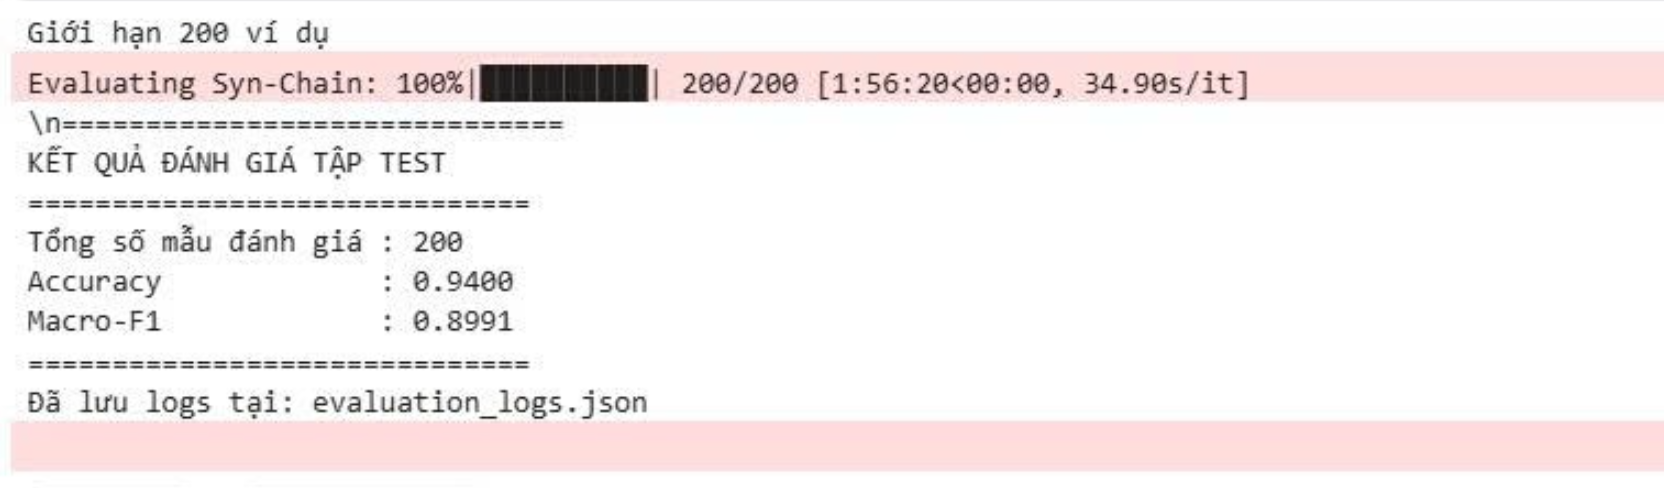
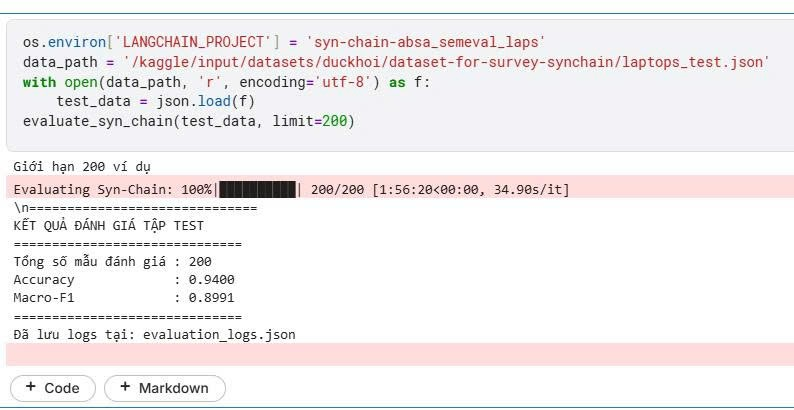

In [7]:
os.environ['LANGCHAIN_PROJECT'] = 'syn-chain-absa_semeval_rest'
data_path = '/kaggle/input/datasets/duckhoi/dataset-for-survey-synchain/restaurants_test.json'
with open(data_path, 'r', encoding='utf-8') as f:
    test_data = json.load(f)
evaluate_syn_chain(test_data, limit=200)

Giới hạn 200 ví dụ


Evaluating Syn-Chain: 100%|██████████| 200/200 [1:54:43<00:00, 34.42s/it]

\n==============================
KẾT QUẢ ĐÁNH GIÁ TẬP TEST
Tổng số mẫu đánh giá : 200
Accuracy             : 0.9600
Macro-F1             : 0.8823
Đã lưu logs tại: evaluation_logs.json
